### Modeling mixed gaussians with EM-Algorithm

To deal with mix of distributions underlying a dataset, the Estimation Maximation algorithm approximates the set of distributions parameters $\theta$ in an iterative fashion. Providing a fixed value for the number of distributions or components, the algorithm will take turns in estimating the true values, and updating the likelihood until a breaking conidition (tolerance) is met. Compared to $k-means$, this method can yield far better results at the cost of computation.

Fortunately, `sklearn` provides a usable implementation in the [mixture](https://scikit-learn.org/stable/modules/mixture.html#mixture) section.

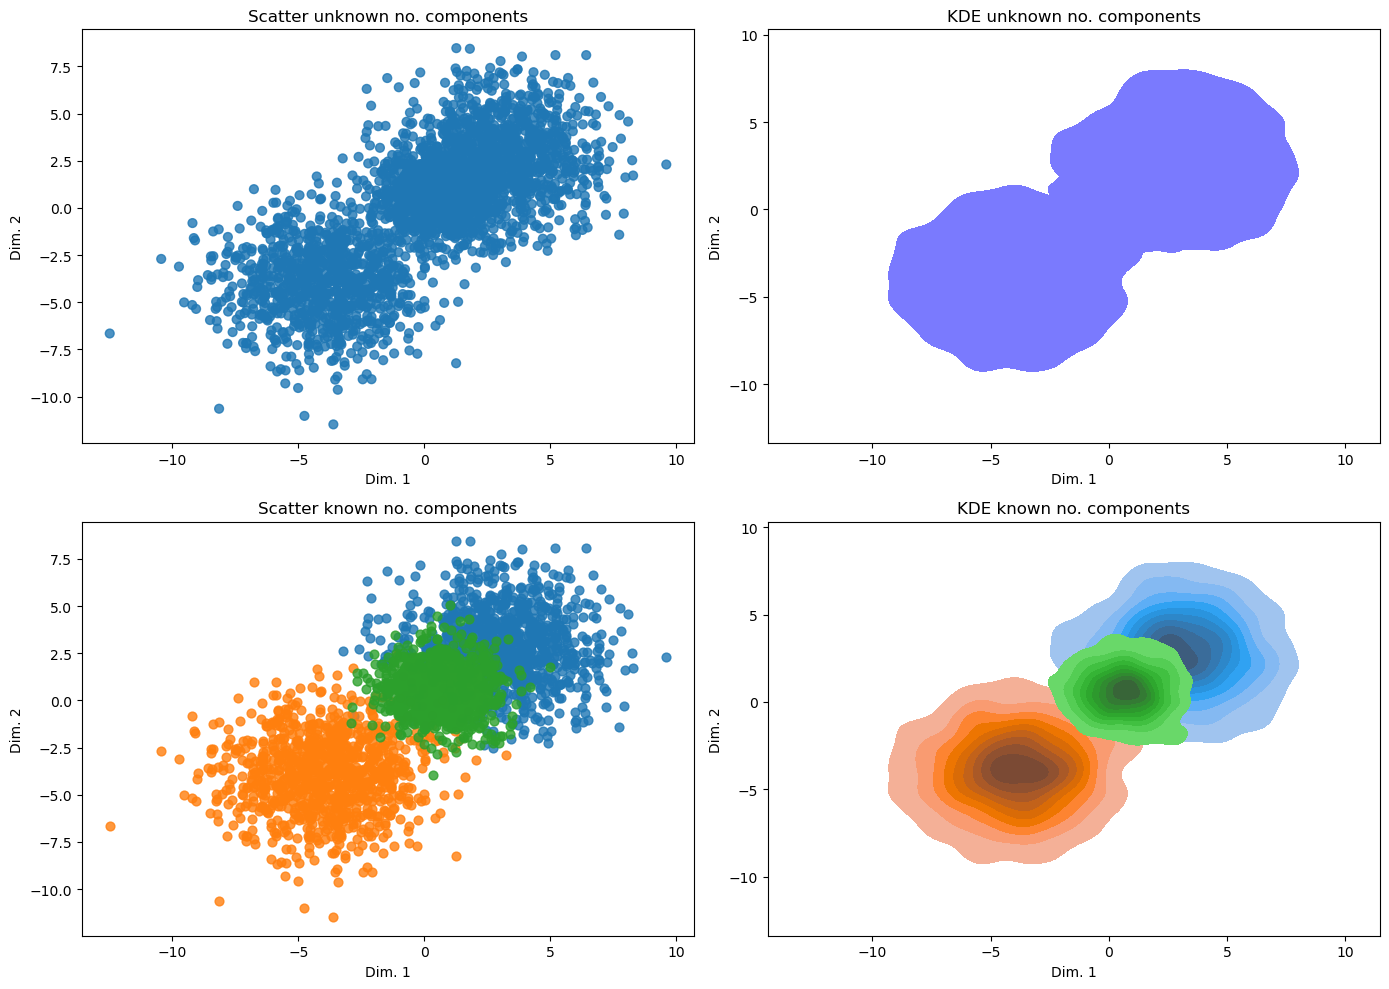

In [101]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# hyperparams
samples = 1000
dimensions = 2
rng = np.random.RandomState(112)
ran_gen = rng.randn(2,3)

# get multi dim data
X = rng.randint(1,5) * rng.normal(ran_gen[0][0], 2 * ran_gen[1][0], (samples, dimensions))
Y = rng.randint(1,5) * rng.normal(ran_gen[0][1], 2 * ran_gen[1][1], (samples, dimensions))
Z = rng.randint(1,5) * rng.normal(ran_gen[0][2], 2 * ran_gen[1][2], (samples, dimensions))

# plot data
fig = plt.figure(figsize=(14, 10))
ax1 = fig.add_subplot(2, 2, 1)
scatter = ax1.scatter(X[:,0], X[:,1], s=40, alpha=0.8, c=np.full((X.shape[0], 3), (0.12156862745098039, 0.4666666666666667, 0.7058823529411765)))
scatter = ax1.scatter(Y[:,0], Y[:,1], s=40, alpha=0.8, c=np.full((Y.shape[0], 3), (0.12156862745098039, 0.4666666666666667, 0.7058823529411765)))
scatter = ax1.scatter(Z[:,0], Z[:,1], s=40, alpha=0.8, c=np.full((Z.shape[0], 3), (0.12156862745098039, 0.4666666666666667, 0.7058823529411765)))
ax1.set_xlabel('Dim. 1')
ax1.set_ylabel('Dim. 2')
ax1.set_title('Scatter unknown no. components')
# fig.colorbar(scatter, ax=ax3d, shrink=0.6, label='Z')

ax2 = fig.add_subplot(2, 2, 2)
sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, levels=2, ax=ax2, color='blue')
sns.kdeplot(x=Y[:, 0], y=Y[:, 1], fill=True, levels=2, ax=ax2, color='blue')
sns.kdeplot(x=Z[:, 0], y=Z[:, 1], fill=True, levels=2, ax=ax2, color='blue')
ax2.set_title('KDE unknown no. components')
ax2.set_xlabel('Dim. 1')
ax2.set_ylabel('Dim. 2')

ax3 = fig.add_subplot(2, 2, 3)
scatter = ax3.scatter(X[:,0], X[:,1], s=40, alpha=0.8)
scatter = ax3.scatter(Y[:,0], Y[:,1], s=40, alpha=0.8)
scatter = ax3.scatter(Z[:,0], Z[:,1], s=40, alpha=0.8)
ax3.set_xlabel('Dim. 1')
ax3.set_ylabel('Dim. 2')
ax3.set_title('Scatter known no. components')
# fig.colorbar(scatter, ax=ax3d, shrink=0.6, label='Z')

ax4 = fig.add_subplot(2, 2, 4)
sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, levels=10, ax=ax4)
sns.kdeplot(x=Y[:, 0], y=Y[:, 1], fill=True, levels=10, ax=ax4)
sns.kdeplot(x=Z[:, 0], y=Z[:, 1], fill=True, levels=10, ax=ax4)
ax4.set_title('KDE known no. components')
ax4.set_xlabel('Dim. 1')
ax4.set_ylabel('Dim. 2')

plt.tight_layout()
plt.show();

Not knowing how many generative distributions determine the data, these plots lead to believe $k = {2,3}$.

In [ ]:
from sklearn.mixture import GaussianMixture

# compare results for k = 2, 3 components
X_train = np.concatenate([X,Y,Z])

k = 2
model_2 = GaussianMixture(n_components=k)
model_2.fit(X_train)

k = 3
model_3 = GaussianMixture(n_components=k)
model_3.fit(X_train)

print(f'µ: {model_2.means_}, cvg: {model_2.converged_}')
print(f'µ: {model_3.means_}, cvg: {model_3.converged_}')

µ: [[ 1.69053387  1.56130321]
 [-4.16685016 -4.13956579]], cvg: True
µ: [[ 0.71348535  0.67143842]
 [-4.0125658  -3.98217771]
 [ 3.40118268  3.13115897]], cvg: True


Avg NLL (2 components): 4.769
Avg NLL (3 components): 4.725


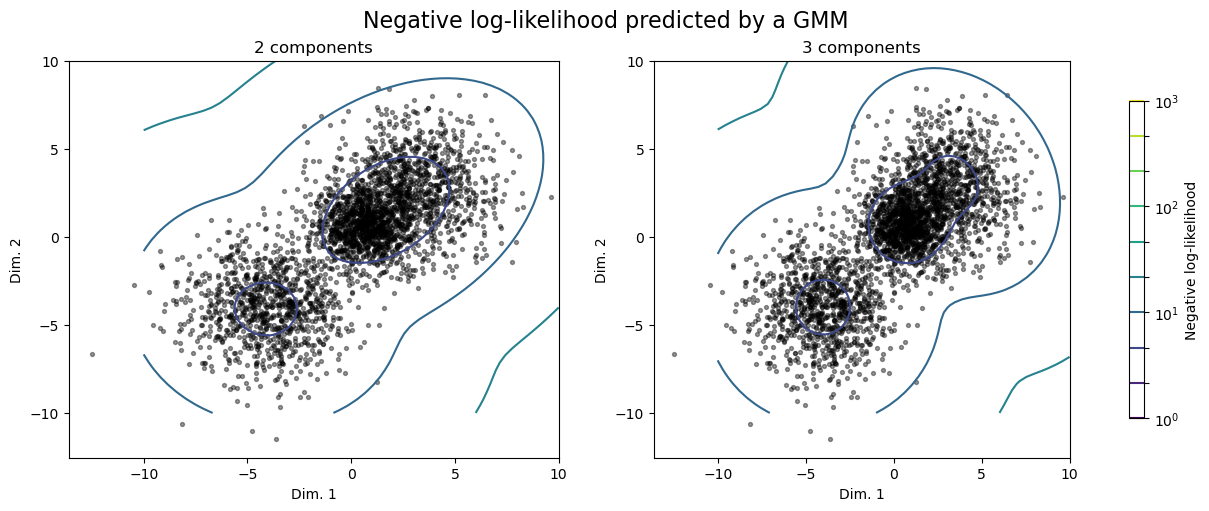

In [138]:
from matplotlib.colors import LogNorm


x = np.linspace(-10.0, 10.0)
y = np.linspace(-10.0, 10.0)
m, n = np.meshgrid(x, y)
mn = np.column_stack([m.ravel(), n.ravel()])

g2 = model_2.score_samples(mn).reshape(m.shape)
g2_minus = -g2
print(f'Avg NLL (2 components): {-model_2.score(X_train):.3f}')

g3 = model_3.score_samples(mn).reshape(m.shape)
g3_minus = -g3
print(f'Avg NLL (3 components): {-model_3.score(X_train):.3f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

cont1 = ax1.contour(
    m, n, g2_minus,
    norm=LogNorm(vmin=1.0, vmax=1000.0),
    levels=np.logspace(0, 3, 10),
    cmap="viridis"
)
ax1.scatter(X_train[:, 0], X_train[:, 1], s=8, c="k", alpha=0.4)
ax1.set_title("2 components")
ax1.set_xlabel("Dim. 1")
ax1.set_ylabel("Dim. 2")

cont2 = ax2.contour(
    m, n, g3_minus,
    norm=LogNorm(vmin=1.0, vmax=1000.0),
    levels=np.logspace(0, 3, 10),
    cmap="viridis"
)
ax2.scatter(X_train[:, 0], X_train[:, 1], s=8, c="k", alpha=0.4)
ax2.set_title("3 components")
ax2.set_xlabel("Dim. 1")
ax2.set_ylabel("Dim. 2")
ax2.set_aspect("equal", adjustable="box")

fig.suptitle("Negative log-likelihood predicted by a GMM", fontsize=16)
fig.colorbar(cont2, ax=(ax1, ax2), shrink=0.8, extend="both", label="Negative log-likelihood")

plt.show()

Only very slightly better is the lower $NLL$ value of the 3 component model, thus we take it. Feel free to change the generating parameters to experience a different outcome.

In [124]:
components = 3
X_train = np.concatenate([X,Y,Z])
model = model_3
model

,"n_components n_components: int, default=1The number of mixture components.",3
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None


Text(0, 0.5, '')

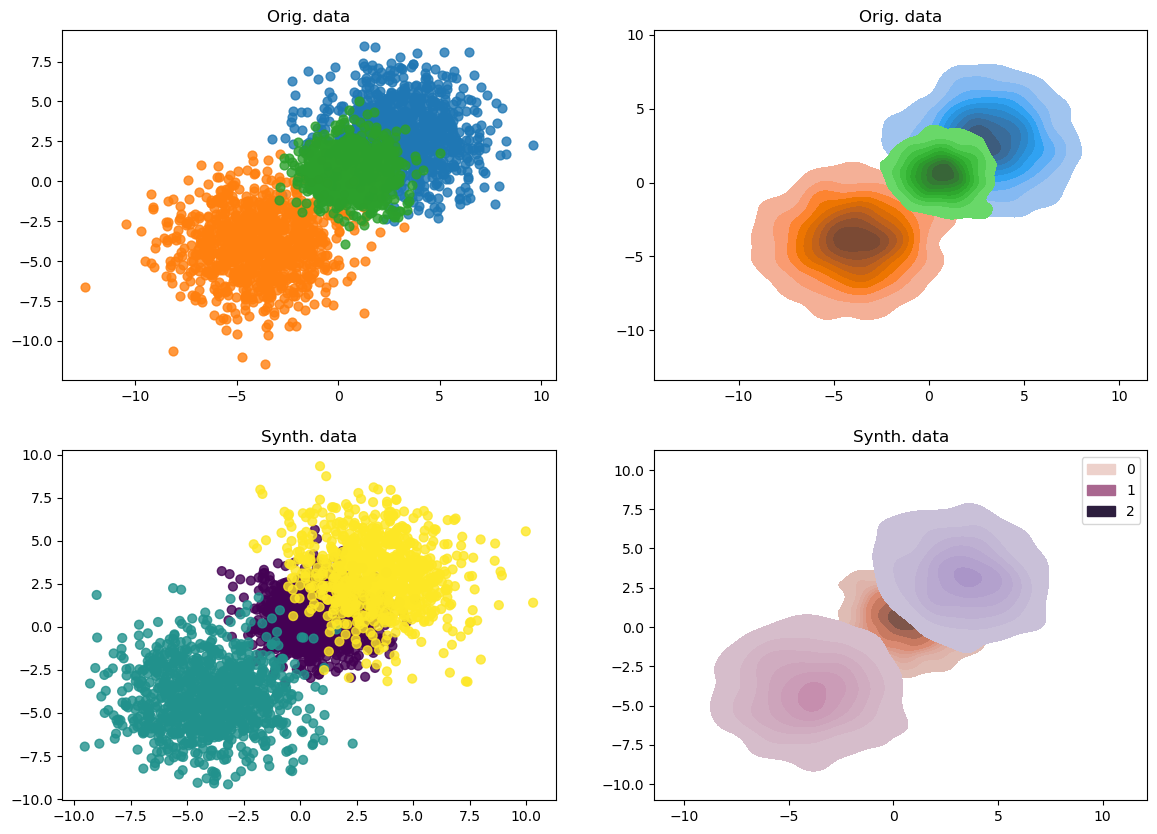

In [139]:
# lets compare the orig data to a synthetic dataset generated by the learned theta of the model

fig = plt.figure(figsize=(14, 10))

ax1 = fig.add_subplot(2, 2, 1)
scatter = ax1.scatter(X[:,0], X[:,1], s=40, alpha=0.8)
scatter = ax1.scatter(Y[:,0], Y[:,1], s=40, alpha=0.8)
scatter = ax1.scatter(Z[:,0], Z[:,1], s=40, alpha=0.8)
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_title('Orig. data')

ax2 = fig.add_subplot(2, 2, 2)
sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, levels=10, ax=ax2)
sns.kdeplot(x=Y[:, 0], y=Y[:, 1], fill=True, levels=10, ax=ax2)
sns.kdeplot(x=Z[:, 0], y=Z[:, 1], fill=True, levels=10, ax=ax2)
ax2.set_title('Orig. data')
ax2.set_xlabel('')
ax2.set_ylabel('')

X_synth, labels = model.sample(samples * components)

ax3 = fig.add_subplot(2, 2, 3)
scatter = ax3.scatter(X_synth[:,0], X_synth[:,1], s=40, alpha=0.8, c=labels)
ax3.set_xlabel('')
ax3.set_ylabel('')
ax3.set_title('Synth. data')
# fig.colorbar(scatter, ax=ax3d, shrink=0.6, label='Z')

ax4 = fig.add_subplot(2, 2, 4)
sns.kdeplot(x=X_synth[:, 0], y=X_synth[:, 1], fill=True, levels=10, ax=ax4, hue=labels)
ax4.set_title('Synth. data')
ax4.set_xlabel('')
ax4.set_ylabel('')